 Step 1: Loading catalogs...
 Step 2: Calculating all std dev profiles...
   Found 5 valid profiles
 Step 3: Generating figures...
  ✅ dstation_02.cnv


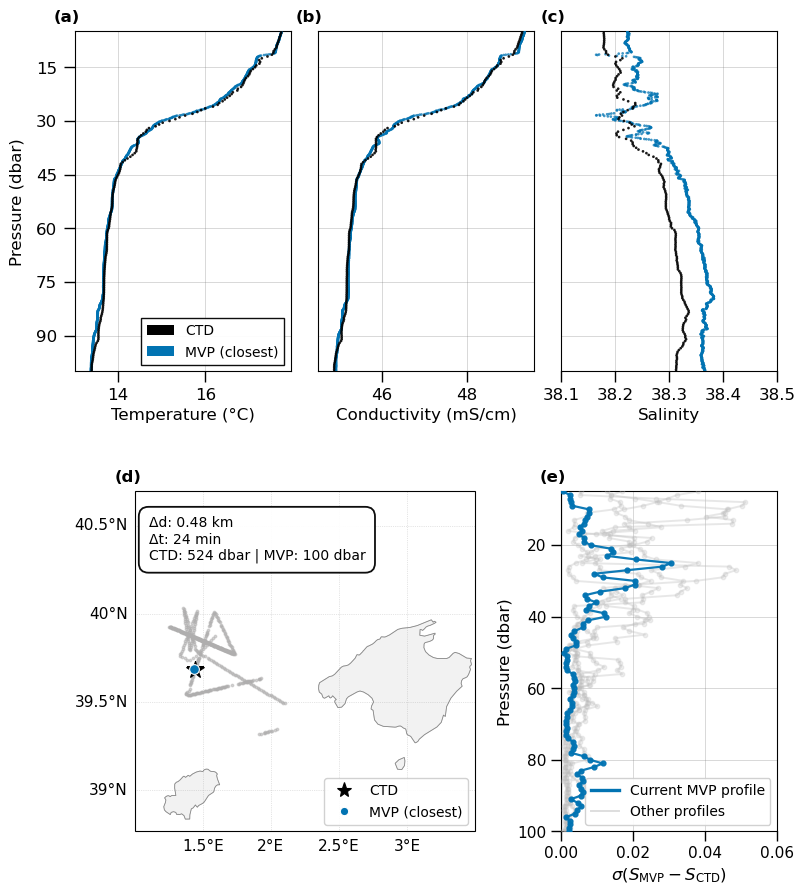

  ✅ dstation_04.cnv


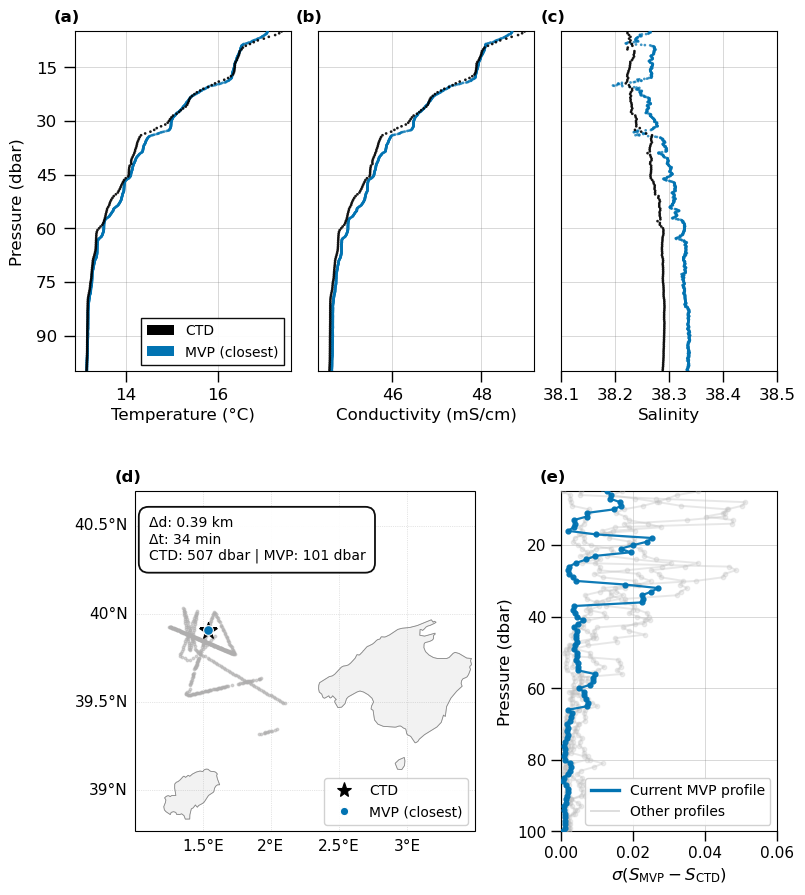

  ✅ dstation_09.cnv


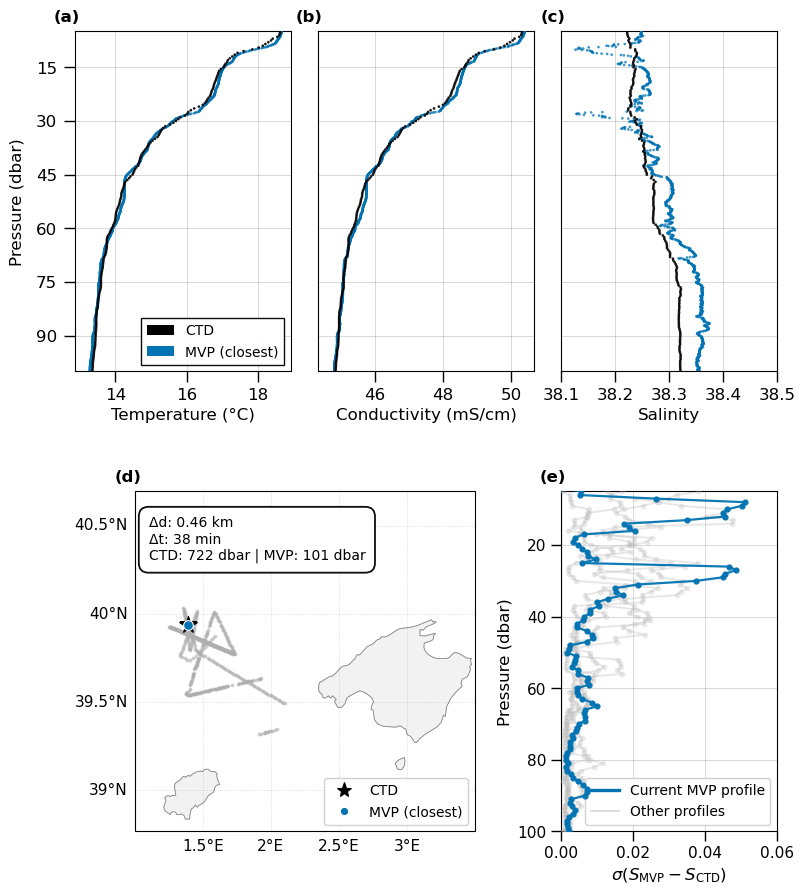

  ✅ dstation_10.cnv


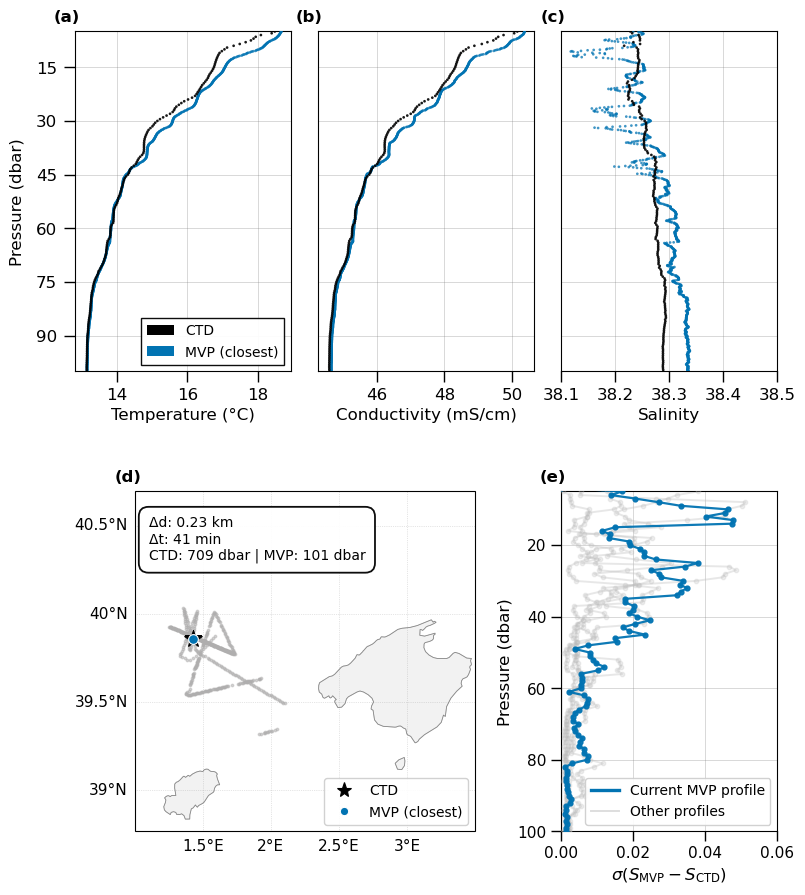

  ✅ dstation_11.cnv


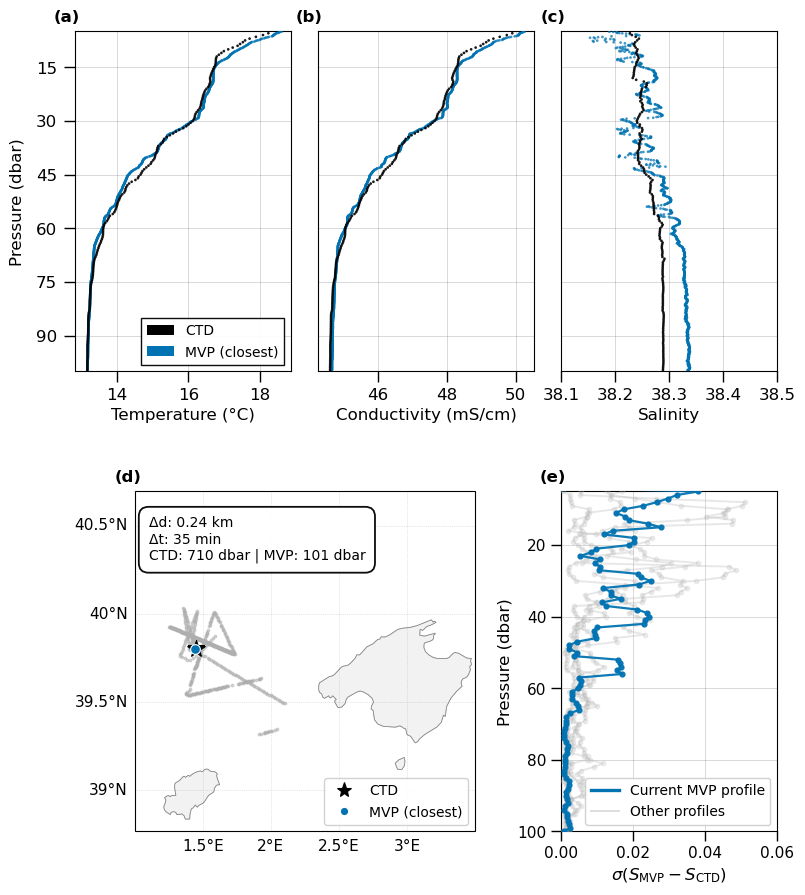


 Done. 5 figures generated in C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing\Figures\figure1_paper_fastswot_v2.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
from geopy.distance import geodesic
import re
import io
import warnings
import gsw
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore")

# ==========================================
# 1. PARAMETERS
# ==========================================
BASE_ROOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing")
DIR_MVP_RAW = BASE_ROOT / "Data" / "Leg1" / "processed_step1_highres_qc" 
DIR_CTD = Path(r"C:/Users/ASUS/OneDrive - Universitat de les Illes Balears/SWOT/CTD/CTD_data/leg1/HM/")

MAX_DIST_KM = 0.5
MAX_TIME_MIN = 60.0

#  Visual Configuration
Z_MAX_PROFILE = 100.0
Z_RANGE_DIFF = (10, 100)
SAL_LIMITS = (38.1, 38.5)
Z_MAX_STDDEV = 100.0
STDDEV_WINDOW = 5.0  # Window size for std dev calculation (dbar)

OUTDIR = BASE_ROOT / "Figures" / "figure1_paper_fastswot_v2"
OUTDIR.mkdir(exist_ok=True)

# ==========================================
# 2. FUNCTIONS
# ==========================================
def parse_cnv_time(line):
    try:
        parts = line.split('=')[1].strip().split('[')[0].strip()
        return pd.to_datetime(parts)
    except: return pd.NaT

def read_ctd_cnv(path):
    try:
        with open(path, 'r', encoding='latin-1') as f: lines = f.readlines()
        lat, lon, time_val = np.nan, np.nan, pd.NaT
        start_idx = 0
        col_map = {}
        name_re = re.compile(r"#\s*name\s*(\d+)\s*=\s*([^:]+)", re.I)
        
        for i, line in enumerate(lines):
            if 'NMEA Latitude' in line:
                parts = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if len(parts)>=2: lat = float(parts[0]) + float(parts[1])/60 * (-1 if 'S' in line else 1)
            if 'NMEA Longitude' in line:
                parts = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if len(parts)>=2: lon = float(parts[0]) + float(parts[1])/60 * (-1 if 'W' in line else 1)
            if 'start_time' in line: time_val = parse_cnv_time(line)
            m = name_re.search(line)
            if m:
                idx = int(m.group(1)); name = m.group(2).strip().lower()
                if any(x in name for x in ['prdm', 'pres']): col_map['p'] = idx
                elif any(x in name for x in ['t090c', 'temp']): col_map['t'] = idx
                elif any(x in name for x in ['sal00', 'psal']): col_map['s'] = idx
            if '*END*' in line: start_idx = i+1; break
            
        data_str = "".join(lines[start_idx:])
        df = pd.read_csv(io.StringIO(data_str), delim_whitespace=True, header=None, on_bad_lines='skip')
        out = {'lat': lat, 'lon': lon, 'time': time_val, 'file': path.name}
        for k, idx in col_map.items(): 
            out[k] = df.iloc[:, idx].values if idx < df.shape[1] else np.nan
            
        # Recalcular Conductividad (mS/cm)
        if 's' in out and 't' in out and 'p' in out:
            out['c'] = gsw.C_from_SP(out['s'], out['t'], out['p'])
            
        return out
    except: return None

def load_mvp_catalog_sorted(mvp_dir):
    files = sorted(list(mvp_dir.glob("*.nc")))
    data = []
    for f in files:
        try:
            with xr.open_dataset(f) as ds:
                lat = np.nanmean(ds['lat'].values if 'lat' in ds else ds.latitude.values)
                lon = np.nanmean(ds['lon'].values if 'lon' in ds else ds.longitude.values)
                t_val = pd.NaT
                if 'start_time' in ds: t_val = pd.to_datetime(ds.start_time)
                elif 'time' in ds: 
                    ts = ds.time.values
                    if ts.size > 0: t_val = pd.to_datetime(ts.ravel()[0])
                data.append({'file': f.name, 'lat': lat, 'lon': lon, 'time': t_val, 'path': f})
        except: pass
    return pd.DataFrame(data)

def load_all_ctd_leg1(ctd_dir):
    """Load all CTD positions from Leg1"""
    ctd_list = []
    ctd_files = sorted(list(ctd_dir.glob("d*.cnv")))
    for f in ctd_files:
        ctd = read_ctd_cnv(f)
        if ctd and not np.isnan(ctd['lat']) and not np.isnan(ctd['lon']):
            ctd_list.append({'lat': ctd['lat'], 'lon': ctd['lon'], 'file': f.name})
    return pd.DataFrame(ctd_list)

# ==========================================
# 3. MATCHING
# ==========================================
def find_closest_sequence_strict(ctd, df_mvp):
    if df_mvp.empty or pd.isna(ctd['lat']) or pd.isna(ctd['time']): return None, None
    dists = []
    for _, row in df_mvp.iterrows():
        try:
            d = geodesic((ctd['lat'], ctd['lon']), (row['lat'], row['lon'])).km
            dists.append(d)
        except: dists.append(9999)
    min_dist = np.min(dists)
    best_idx = np.argmin(dists)
    best_mvp = df_mvp.iloc[best_idx].copy()
    best_mvp['dist_to_ctd'] = min_dist 
    
    if min_dist > MAX_DIST_KM: return None, None
    if pd.isna(best_mvp['time']): return None, None
    dt_min = abs((best_mvp['time'] - ctd['time']).total_seconds() / 60.0)
    if dt_min > MAX_TIME_MIN: return None, None
    
    sequence_df = df_mvp.iloc[[best_idx]].copy()
    sequence_df['dist_to_ctd'] = [min_dist]
    return sequence_df, best_mvp

# ==========================================
# 4. CALCULATE STD DEV PROFILES (FIRST PASS)
# ==========================================
def calculate_all_stddev_profiles(DIR_CTD, df_mvp):
    """Calculate std dev profiles for all valid CTD-MVP pairs"""
    all_profiles = []
    ctd_files = sorted(list(DIR_CTD.glob("d*.cnv")))
    
    for ctd_f in ctd_files:
        ctd = read_ctd_cnv(ctd_f)
        if not ctd: continue
        
        mvp_seq, best_match = find_closest_sequence_strict(ctd, df_mvp)
        if mvp_seq is None: continue
        
        # Load best MVP match
        try:
            ds_best = xr.open_dataset(best_match['path'])
        except:
            continue
        
        # Get data
        ctd_p = np.array(ctd['p'], dtype=np.float64)
        if ctd_p.ndim > 1:
            ctd_p = ctd_p.ravel()
        
        ctd_s = np.array(ctd['s'], dtype=np.float64)
        if ctd_s.ndim > 1:
            ctd_s = ctd_s.ravel()
        
        p_mvp = np.array(ds_best['pressure'].values, dtype=np.float64).ravel()
        if 's_raw' in ds_best:
            s_mvp = np.array(ds_best['s_raw'].values, dtype=np.float64).ravel()
        elif 's1' in ds_best:
            s_mvp = np.array(ds_best['s1'].values, dtype=np.float64).ravel()
        else:
            continue
        
        # Calculate std dev profile
        if len(ctd_p) > 1 and len(s_mvp) > 1 and np.all(np.diff(ctd_p) > 0):
            p_grid = np.arange(0, Z_MAX_STDDEV + 1, 1)
            
            # Interpolate to common grid
            s_ctd_grid = np.interp(p_grid, ctd_p, ctd_s, left=np.nan, right=np.nan)
            s_mvp_grid = np.interp(p_grid, p_mvp, s_mvp, left=np.nan, right=np.nan)
            
            # Calculate std dev in rolling windows
            stddev_profile = []
            for p_center in p_grid:
                p_min = p_center - STDDEV_WINDOW/2
                p_max = p_center + STDDEV_WINDOW/2
                mask = (p_grid >= p_min) & (p_grid <= p_max)
                
                diff_window = (s_mvp_grid[mask] - s_ctd_grid[mask])
                if len(diff_window) > 1 and not np.all(np.isnan(diff_window)):
                    stddev_profile.append(np.nanstd(diff_window))
                else:
                    stddev_profile.append(np.nan)
            
            stddev_profile = np.array(stddev_profile)
            
            all_profiles.append({
                'p_grid': p_grid,
                'stddev': stddev_profile,
                'ctd_file': ctd['file'] if 'file' in ctd else ctd_f.name,
                'color': '#0173B2'  # Blue for matched profiles
            })
    
    return all_profiles

# ==========================================
# 5. FINAL FIGURE
# ==========================================
def plot_figure_1_final_equal(ctd_data, mvp_seq, best_match, save_path, df_mvp_all, df_ctd_all, all_stddev_profiles):
    
    mvp_data = []
    for _, row in mvp_seq.iterrows():
        try:
            ds = xr.open_dataset(row['path'])
            mvp_data.append({'ds': ds, 'dist': row['dist_to_ctd'], 'name': row['file']})
        except: pass
    if not mvp_data: return

    # Color palette by variable (paper-style storytelling)
    color_best = '#0173B2'      # Salinity theme (blue)
    color_raw = '#B0B0B0'       # Neutral for adjacent profiles
    color_ctd = '#000000'       # CTD always black

    colors = []
    for m in mvp_data:
        if m['name'] == best_match['file']: colors.append(color_best)
        else: colors.append(color_raw)

    # --- FIGURE with 2 rows ---
    fig = plt.figure(figsize=(13.5, 10)) 
    
    # Manual layout for publication-style geometry:
    # (a,b,c,e,f) same narrow/tall size, (d) larger and square
    profile_w = 0.16
    profile_h = 0.34
    top_y = 0.58
    bottom_y = 0.12
    gap = 0.02
    top_total_w = 3 * profile_w + 2 * gap
    left = 0.5 - top_total_w / 2

    x_a = left
    x_b = x_a + profile_w + gap
    x_c = x_b + profile_w + gap

    map_w = 2 * profile_w + gap
    map_h = 0.34
    bottom_total_w = map_w + gap + profile_w
    x_map = 0.5 - bottom_total_w / 2
    y_map = bottom_y

    x_e = x_map + map_w + gap

    ax_t = fig.add_axes([x_a, top_y, profile_w, profile_h])
    ax_c = fig.add_axes([x_b, top_y, profile_w, profile_h])
    ax_s = fig.add_axes([x_c, top_y, profile_w, profile_h])

    ax_map = fig.add_axes([x_map, y_map, map_w, map_h], projection=ccrs.Mercator())
    ax_stddev = fig.add_axes([x_e, bottom_y, profile_w, profile_h])
    ax_map.set_box_aspect(1)

    # Convert CTD pressure to 1D float array
    ctd_p = np.array(ctd_data['p'], dtype=np.float64)
    if ctd_p.ndim > 1:
        ctd_p = ctd_p.ravel()
    
    ctd_s = np.array(ctd_data['s'], dtype=np.float64)
    if ctd_s.ndim > 1:
        ctd_s = ctd_s.ravel()

    # --- CTD ---
    kw_ctd_t = {'s': 15, 'color': color_ctd, 'marker': '.', 'label': 'CTD', 'zorder': 10, 'alpha': 0.9, 'edgecolors': 'none'}
    kw_ctd_c = {'s': 15, 'color': color_ctd, 'marker': '.', 'label': 'CTD', 'zorder': 10, 'alpha': 0.9, 'edgecolors': 'none'}
    kw_ctd_s = {'s': 15, 'color': color_ctd, 'marker': '.', 'label': 'CTD', 'zorder': 10, 'alpha': 0.9, 'edgecolors': 'none'}
    ax_t.scatter(ctd_data['t'], ctd_p, **kw_ctd_t)
    ax_s.scatter(ctd_s, ctd_p, **kw_ctd_s)
    if 'c' in ctd_data: ax_c.scatter(ctd_data['c'], ctd_p, **kw_ctd_c)

    # --- MVP ---
    lats, lons = [], []
    
    for i, m in enumerate(mvp_data):
        ds = m['ds']
        p = np.array(ds['pressure'].values, dtype=np.float64).ravel()
        t = np.array(ds['t1'].values, dtype=np.float64).ravel()
        c = np.array(ds['c1'].values, dtype=np.float64).ravel()
        if 's_raw' in ds:
            s = np.array(ds['s_raw'].values, dtype=np.float64).ravel()
        elif 's1' in ds:
            s = np.array(ds['s1'].values, dtype=np.float64).ravel()
        else:
            s = np.full_like(p, np.nan)
        
        col = colors[i]
        ax_t.scatter(t, p, s=15, color=col, alpha=0.75, marker='.', edgecolors='none', zorder=3)
        ax_c.scatter(c, p, s=15, color=col, alpha=0.75, marker='.', edgecolors='none', zorder=3)
        ax_s.scatter(s, p, s=15, color=col, alpha=0.75, marker='.', edgecolors='none', zorder=3)
        
        lats.append(np.nanmean(ds['lat'].values if 'lat' in ds else ds.latitude.values))
        lons.append(np.nanmean(ds['lon'].values if 'lon' in ds else ds.longitude.values))

    for ax in [ax_t, ax_c, ax_s]:
        ax.invert_yaxis()
        ax.set_ylim(Z_MAX_PROFILE, 5)
        
        # Enhanced grid - Publication quality
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.7, color='#808080')
        ax.set_axisbelow(True)
        
        # # Enhanced spines - thicker for publication
        # for spine_name, spine in ax.spines.items():
        #     spine.set_linewidth(1.5)
        #     spine.set_color('black')
        
        # Y-axis formatting with smart tick placement
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=7))
        ax.tick_params(axis='y', which='major', pad=5, labelsize=12, width=1, length=8)
        
        # X-axis tick formatting
        ax.tick_params(axis='x', which='major', labelsize=12, width=1, length=8)
        
        if ax != ax_t:
            ax.set_yticklabels([])
            ax.set_ylabel("")
            ax.tick_params(axis='y', which='both', left=False)
            
    ax_c.set_yticklabels([])
    ax_c.set_ylabel("")

    ax_t.set_xlabel("Temperature (°C)", fontsize=12)
    ax_t.set_ylabel("Pressure (dbar)", fontsize=12, labelpad=8)
    
    ax_c.set_xlabel("Conductivity (mS/cm)", fontsize=12) 
    
    ax_s.set_xlabel("Salinity", fontsize=12)
    ax_s.set_xlim(SAL_LIMITS[0], SAL_LIMITS[1])

    # Create legend elements 
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor=color_ctd, label='CTD'),
        Patch(facecolor=color_best, label='MVP (closest)')
    ]

    # --- STDDEV PANEL: Plot ALL std dev profiles (same in every figure) ---
    if all_stddev_profiles:
        ax_stddev.axvline(0, color='k', linestyle='-', alpha=0.3, lw=1)
        
        current_ctd_file = ctd_data.get('file', None)
        for profile_data in all_stddev_profiles:
            p_grid = profile_data['p_grid']
            stddev = profile_data['stddev']
            is_current = (current_ctd_file is not None and profile_data.get('ctd_file') == current_ctd_file)
            
            # Highlight current profile; keep others shaded
            if is_current:
                ax_stddev.plot(stddev, p_grid, color=color_best, linewidth=1.6, alpha=0.95, zorder=6)
                ax_stddev.scatter(stddev, p_grid, s=12, color=color_best, alpha=0.95, zorder=7)
            else:
                ax_stddev.plot(stddev, p_grid, color='#BDBDBD', linewidth=1.4, alpha=0.35, zorder=2)
                ax_stddev.scatter(stddev, p_grid, s=10, color='#BDBDBD', alpha=0.25, zorder=3)
        
        ax_stddev.invert_yaxis()
        ax_stddev.set_ylim(Z_MAX_STDDEV, 5)
        ax_stddev.set_xlim(0, 0.06)
        ax_stddev.set_xlabel(r"$\sigma (S_{\mathrm{MVP}}-S_{\mathrm{CTD}})$", fontsize=12)
        ax_stddev.set_ylabel("Pressure (dbar)", fontsize=12)
        ax_stddev.grid(True, alpha=0.3, linestyle='-', linewidth=0.7, color='#808080')
        ax_stddev.set_axisbelow(True)
        
        # Enhanced spines
        # for spine_name, spine in ax_stddev.spines.items():
        #     spine.set_linewidth(1.5)
        #     spine.set_color('black')
        
        ax_stddev.tick_params(labelsize=11, width=1, length=7)
        std_legend = [
            Line2D([0], [0], color=color_best, lw=2.4, label='Current MVP profile'),
            Line2D([0], [0], color='#BDBDBD', lw=1.4, alpha=0.5, label='Other profiles')
        ]
        ax_stddev.legend(handles=std_legend, loc='lower right', fontsize=10, framealpha=0.9)

    # --- MAP: FULL REGION WITH ALL LEG1 DATA ---
    data_crs = ccrs.PlateCarree()

    # Main map: full region extent
    ax_map.set_extent([1, 3.5, 38.7, 40.75], crs=data_crs)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='#888888', zorder=2)
    ax_map.add_feature(cfeature.LAND, facecolor='#f2f2f2', edgecolor='#d1d1d1', linewidth=0.5, zorder=1)
    ax_map.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)

    gl = ax_map.gridlines(draw_labels=True, ls=':', color='gray', alpha=0.4, linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 11}
    gl.ylabel_style = {'size': 11}

    # reducir numero de ticks en el mapa
    gl.xlocator = plt.FixedLocator(np.arange(1, 4, 0.5))
    gl.ylocator = plt.FixedLocator(np.arange(38.5, 41, 0.5))

    # Plot ALL MVP Leg1 trajectories
    if not df_mvp_all.empty:
        ax_map.scatter(df_mvp_all['lon'], df_mvp_all['lat'], s=3, color="#afaeae", 
                      alpha=0.5, transform=data_crs, zorder=3)

    # Highlight current CTD and closest MVP position on the main map
    ax_map.plot(ctd_data['lon'], ctd_data['lat'], marker='*', linestyle='None', color=color_ctd, markersize=13, label='Current CTD',
               transform=data_crs, zorder=6, markeredgecolor='k', markeredgewidth=0.8)
    if len(lons) > 0:
        ax_map.plot(lons[0], lats[0], marker='o', linestyle='None', color=color_best, markersize=7,
                    transform=data_crs, zorder=6, markeredgecolor='w', markeredgewidth=0.8)
    # add legend for map points
    map_legend_elements = [
        Line2D([0], [0], marker='*', color='w', label='CTD', markerfacecolor=color_ctd, markersize=11, markeredgecolor='k', markeredgewidth=0.8),
        Line2D([0], [0], marker='o', color='w', label='MVP (closest)', markerfacecolor=color_best, markersize=6, markeredgecolor='w', markeredgewidth=0.8)
    ]
    ax_map.legend(handles=map_legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

    # Info box on main map with extended information
    dt = abs((best_match['time'] - ctd_data['time']).total_seconds()/60)

    # Get depth information
    ctd_depth = ctd_p.max() if len(ctd_p) > 0 else np.nan
    best_mvp_data = None
    for m in mvp_data:
        if m['name'] == best_match['file']:
            best_mvp_data = m['ds']
            break
    mvp_depth = best_mvp_data['pressure'].max() if best_mvp_data is not None else np.nan

    # Build info string with extended details
    info_str = f"\u0394d: {best_match['dist_to_ctd']:.2f} km\n\u0394t: {dt:.0f} min"
    if not np.isnan(ctd_depth) and not np.isnan(mvp_depth):
        info_str += f"\nCTD: {ctd_depth:.0f} dbar | MVP: {mvp_depth:.0f} dbar"
    elif not np.isnan(ctd_depth):
        info_str += f"\nCTD depth: {ctd_depth:.0f} dbar"

    ax_map.text(0.04, 0.8, info_str, transform=ax_map.transAxes,
                fontsize=10, bbox=dict(facecolor='white', alpha=0.95, boxstyle='round,pad=0.7', 
                edgecolor='black', linewidth=1.3), zorder=10)

    # Panel labels in paper style (top-right)
    ax_t.text(0.02, 1.02, '(a)', transform=ax_t.transAxes, ha='right', va='bottom', fontsize=12, fontweight='bold')
    ax_c.text(0.02, 1.02, '(b)', transform=ax_c.transAxes, ha='right', va='bottom', fontsize=12, fontweight='bold')
    ax_s.text(0.02, 1.02, '(c)', transform=ax_s.transAxes, ha='right', va='bottom', fontsize=12, fontweight='bold')
    ax_map.text(0.02, 1.02, '(d)', transform=ax_map.transAxes, ha='right', va='bottom', fontsize=12, fontweight='bold')
    ax_stddev.text(0.02, 1.02, '(e)', transform=ax_stddev.transAxes, ha='right', va='bottom', fontsize=12, fontweight='bold')

    ax_t.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.95, edgecolor='black', fancybox=False)

    # Manual axes positions are already optimized for final layout

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    plt.close()

# ==========================================
# 5. EXECUTION
# ==========================================
if __name__ == "__main__":
    print(f" Step 1: Loading catalogs...")
    df_mvp = load_mvp_catalog_sorted(DIR_MVP_RAW)
    if df_mvp.empty: exit()
    
    df_ctd_all = load_all_ctd_leg1(DIR_CTD)
    
    print(f" Step 2: Calculating all std dev profiles...")
    all_stddev_profiles = calculate_all_stddev_profiles(DIR_CTD, df_mvp)
    print(f"   Found {len(all_stddev_profiles)} valid profiles")
    
    print(f" Step 3: Generating figures...")
    
    ctd_files = sorted(list(DIR_CTD.glob("d*.cnv")))
    
    hits = 0
    for ctd_f in ctd_files:
        ctd = read_ctd_cnv(ctd_f)
        if not ctd: continue
        
        mvp_seq, best_match = find_closest_sequence_strict(ctd, df_mvp)
        
        if mvp_seq is not None:
            print(f"  ✅ {ctd_f.name}")
            savename = OUTDIR / f"Fig1_Equal_{ctd_f.stem}.png"
            try:
                plot_figure_1_final_equal(ctd, mvp_seq, best_match, savename, df_mvp, df_ctd_all, all_stddev_profiles)
                hits += 1
            except Exception as e:
                print(f"     ❌ Error: {e}")

    print(f"\n Done. {hits} figures generated in {OUTDIR}.")